Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('../data/ethiopia.csv', encoding='latin1')
print(df.head())
df.head()

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   

   WS2M_MAX     PS  QV2M  
0      5.07  77.13  4.00  
1      4.19  77.14  3.35  
2      2.76  77.11  3.43  
3      1.28  77.07  4.60  
4      2.14  77.01  5.58  


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [3]:
# Add a Country column to identify the dataset
df['country'] = 'Ethiopia'
#Proper datetime format
df['date'] = pd.to_datetime(df['YEAR']* 1000 + df["DOY"], format='%Y%j')
#Extract month
df['month'] = df['date'].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


Summary Statistics & Missing-Value Report

In [4]:
# Repalce all occurences of -999
df = df.replace(-999, np.nan)
df.duplicated().sum()
df.describe()
#write a 

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [5]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
month          0
dtype: int64

Identify outliers using z-scores

In [6]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [7]:
z_scores = np.abs(stats.zscore(df[cols_to_check]))

In [8]:
outliers_mask = (z_scores > 3).any(axis=1)

In [9]:
print(f"\n Rows flagged as outliers: {outliers_mask.sum()}")


 Rows flagged as outliers: 132


In [10]:
df_clean = df[~outliers_mask].copy()

In [11]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Remaining negatives: {(df_clean[cols_to_check] < 0).sum().sum()}")

Original rows: 4108
Cleaned rows: 3976
Remaining negatives: 0


Handle Missing Values

In [12]:
print(df.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'country', 'date', 'month'],
      dtype='object')


In [13]:
missing_30 = (df.isnull().mean(axis=1) > 0.3).sum()
print("Number of rows with >30% missing values:", missing_30)

Number of rows with >30% missing values: 0


In [14]:
df.to_csv('../data/ethiopia_clean.csv', index=False)

Time Series Analysis

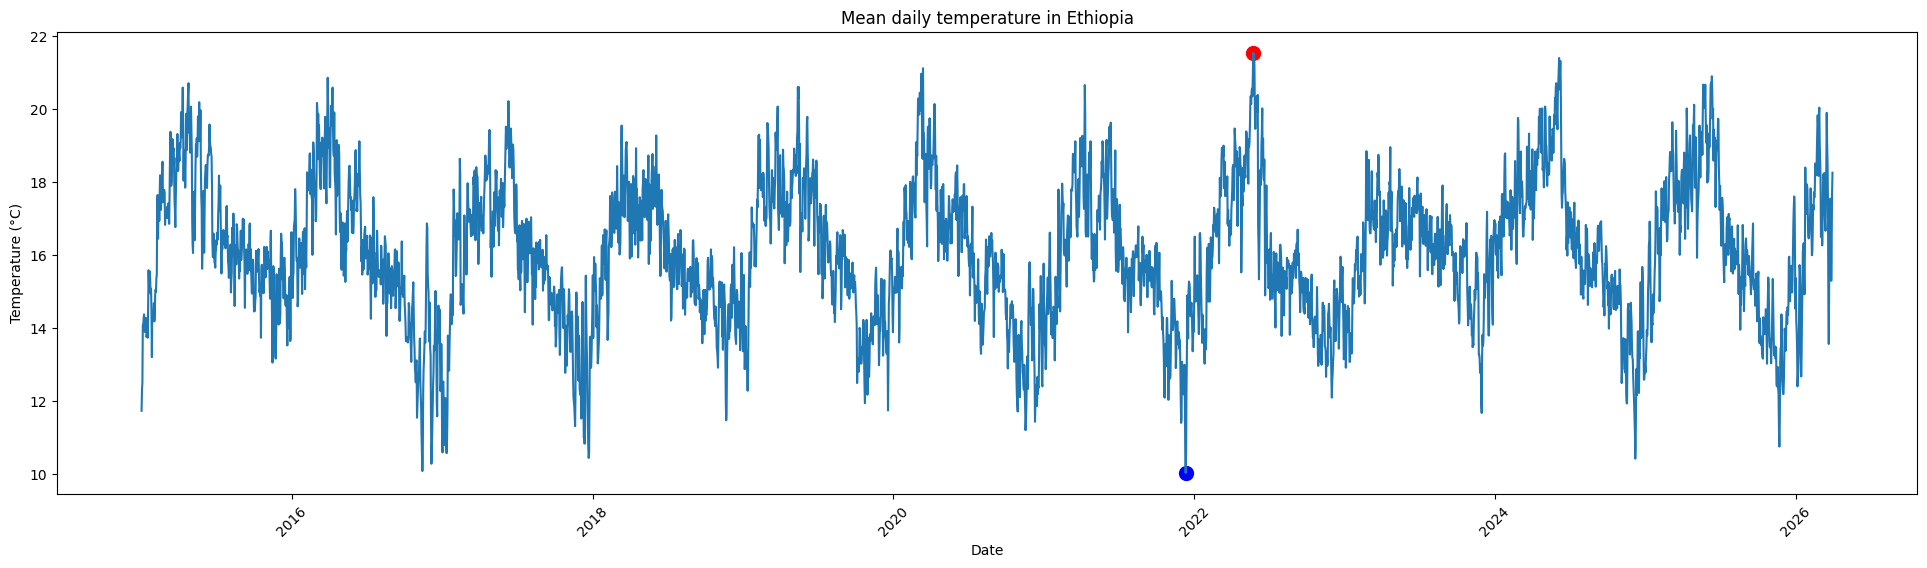

In [33]:
plt.figure(figsize=(24, 6))
plt.plot('date', 'T2M', data=df)

#Add title and labels
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Mean daily temperature in Ethiopia')

# Rotate x-axis labels by 45 degrees for better visibility
plt.xticks(rotation=45)

#Find the index of the maximum temperature
max_temp_index = df['T2M'].idxmax()
min_temp_index = df['T2M'].idxmin()

#Annotate the maximum temperature point
plt.scatter(df['date'].iloc[max_temp_index], df['T2M'].iloc[max_temp_index],
            color='red', marker='o', s=[100], label='Max Temp')

#Annotate the minimum temperature point
plt.scatter(df['date'].iloc[min_temp_index], df['T2M'].iloc[min_temp_index],
            color='blue', marker='o', s=[100], label='Min Temp')

#Display the plot
plt.show()

Bar Plot Chart

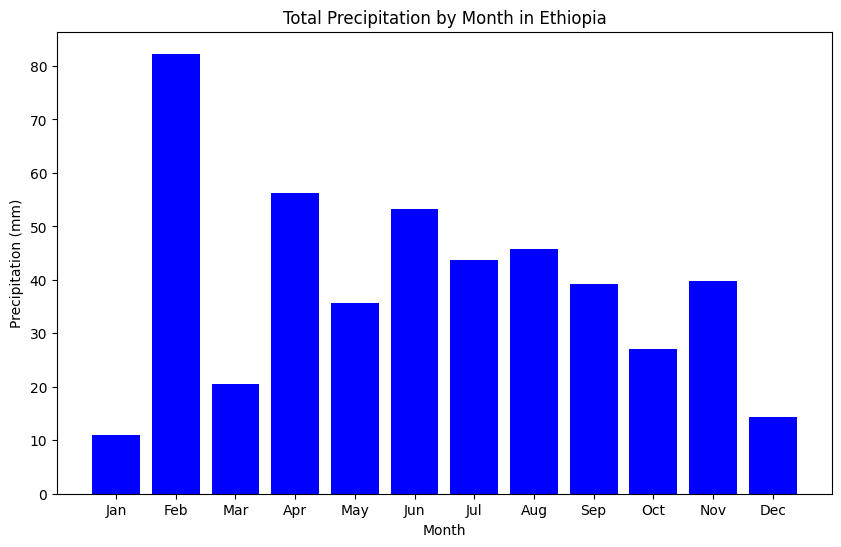

In [31]:
# Aggregate total precipitation by month
monthly_precip = df.groupby('month')['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 6))
plt.bar(df['month'], df['PRECTOTCORR'], color='blue')
plt.title('Total Precipitation by Month in Ethiopia')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.xticks(df['month'].unique(), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

Correlation & Relationship Analysis

Heatmap of correlations across all numeric columns

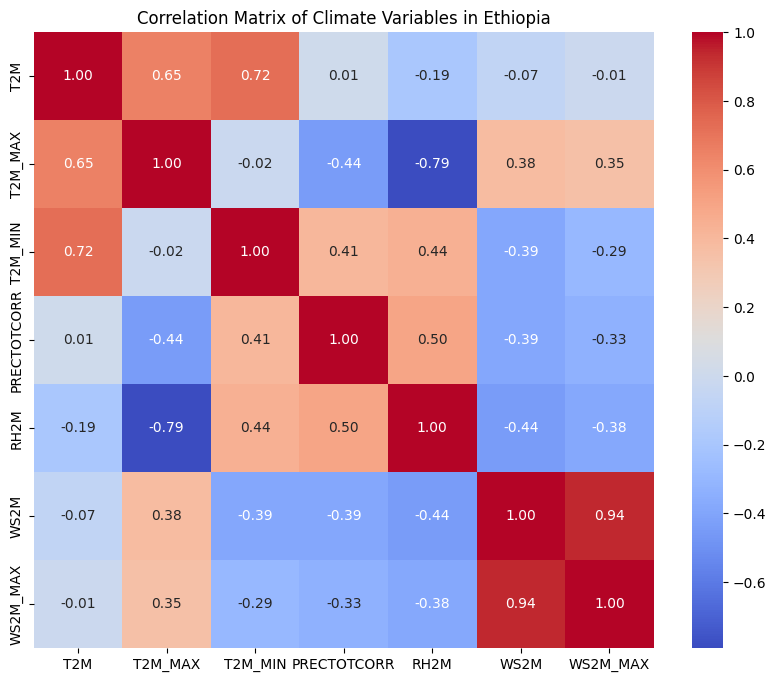

In [32]:
corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Climate Variables in Ethiopia')
plt.show()

Scatter Plot 

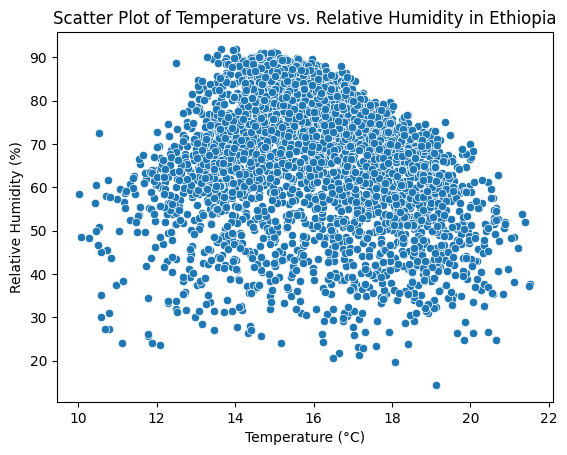

In [34]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Ethiopia')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

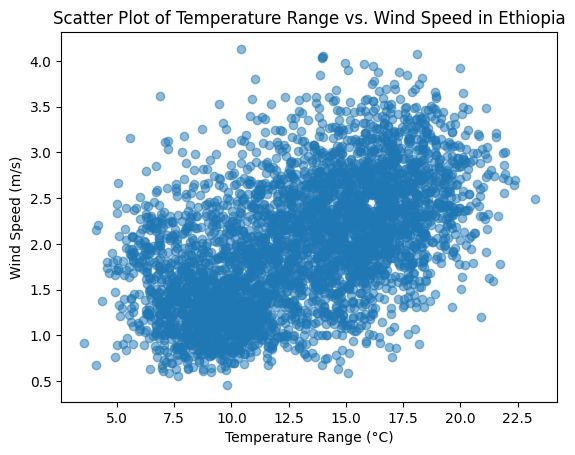

In [35]:
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.5)
plt.title('Scatter Plot of Temperature Range vs. Wind Speed in Ethiopia')
plt.xlabel('Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

Distribution Analysis

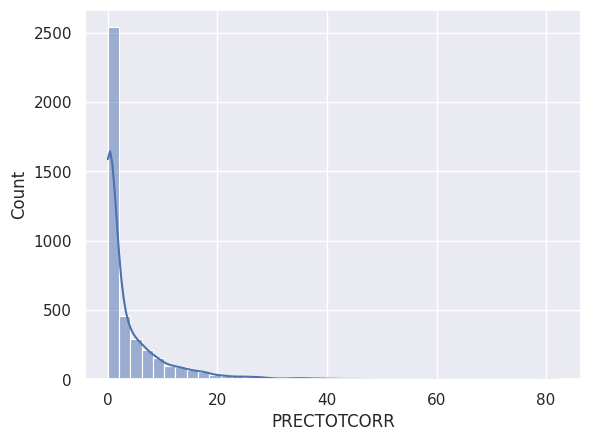

In [ ]:
sns.set_theme(style="darkgrid")
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True)

plt.show()

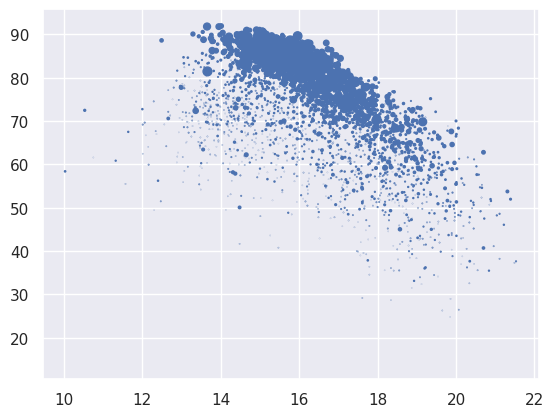

In [ ]:
plt.scatter(x='T2M', y='RH2M', data=df, s='PRECTOTCORR')